# Etapa 3 – Transfer Learning com PyTorch
Classificação de cães e gatos utilizando modelos pré-treinados do TorchVision.
São usadas **duas arquiteturas**: **ResNet-18** e **MobileNet V2**, com fine-tuning nas camadas finais.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os
import time

## Configurações

In [2]:
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE    = 32
EPOCHS        = 10        # fine-tuning requer menos épocas
LEARNING_RATE = 0.001
DATASET_DIR   = 'datasets'  # ajuste se necessário
NUM_CLASSES   = 2

print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


## Pré-processamento e Data Augmentation

Técnicas aplicadas no treino (três grupos distintos):
1. **Geométrico** – `RandomHorizontalFlip`
2. **Rotação** – `RandomRotation(10°)`
3. **Cor** – `ColorJitter` (brilho, contraste, saturação)

Normalização ImageNet para compatibilidade com os pesos pré-treinados.

In [3]:
# Média e desvio padrão do ImageNet (exigidos pelos modelos pré-treinados)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # 1. Geométrico
    transforms.RandomHorizontalFlip(),
    # 2. Rotação
    transforms.RandomRotation(10),
    # 3. Cor
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## Carregamento do Dataset

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, 'train'),      transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_DIR, 'validation'), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATASET_DIR, 'test'),       transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Classes: {train_dataset.classes}')   # ['cat', 'dog']
print(f'Train: {len(train_dataset)} imagens')
print(f'Val:   {len(val_dataset)} imagens')
print(f'Test:  {len(test_dataset)} imagens')

Classes: ['cat', 'dog']
Train: 300 imagens
Val:   100 imagens
Test:  100 imagens


## Funções Auxiliares de Treino e Avaliação

In [5]:
def train_model(model, optimizer, criterion, epochs, model_name):
    """Treina e valida o modelo, retornando histórico de losses."""
    train_losses, val_losses = [], []
    start = time.time()

    for epoch in range(epochs):
        # ========================
        # TREINO
        # ========================
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ========================
        # VALIDAÇÃO
        # ========================
        model.eval()
        val_running_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_running_loss += loss.item()

        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'[{model_name}] Época {epoch+1:2d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    elapsed = time.time() - start
    print(f'[{model_name}] Tempo de treinamento: {elapsed:.2f}s\n')
    return train_losses, val_losses, elapsed


def evaluate_model(model, model_name):
    """Avalia o modelo no conjunto de teste e exibe métricas."""
    model.eval()
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    cm = confusion_matrix(all_labels, all_preds)
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f'=== {model_name} – Resultados no Teste ===')
    print(f'Acurácia:  {accuracy:.2f}%')
    print(f'Precisão:  {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'\nMatriz de Confusão:')
    print(f'              Predito Gato  Predito Cachorro')
    print(f'Real Gato         {TN:5d}          {FP:5d}')
    print(f'Real Cachorro     {FN:5d}          {TP:5d}\n')

    return accuracy, cm

---
## Modelo 1 – ResNet-18 (Fine-tuning)

Apenas a última camada fully connected é substituída e treinada.
As demais camadas têm seus pesos congelados.

In [6]:
# Importação do modelo pré-treinado
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelar todas as camadas (feature extractor)
for param in resnet.parameters():
    param.requires_grad = False

# Configuração da camada final para fine-tuning
# resnet.fc: Linear(512, 1000) → Linear(512, 2)
in_features = resnet.fc.in_features
resnet.fc   = nn.Linear(in_features, NUM_CLASSES)

resnet = resnet.to(DEVICE)

# Apenas os parâmetros da camada final são otimizados
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=LEARNING_RATE)
criterion_resnet = nn.CrossEntropyLoss()

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet-18 – Parâmetros treináveis: {trainable:,}')

ResNet-18 – Parâmetros treináveis: 1,026


In [7]:
resnet_train_losses, resnet_val_losses, resnet_time = train_model(
    resnet, optimizer_resnet, criterion_resnet, EPOCHS, 'ResNet-18'
)

[ResNet-18] Época  1/10 | Train Loss: 0.6867 | Val Loss: 0.5823
[ResNet-18] Época  2/10 | Train Loss: 0.3916 | Val Loss: 0.3691
[ResNet-18] Época  3/10 | Train Loss: 0.2939 | Val Loss: 0.3567
[ResNet-18] Época  4/10 | Train Loss: 0.2192 | Val Loss: 0.3006
[ResNet-18] Época  5/10 | Train Loss: 0.1895 | Val Loss: 0.2626
[ResNet-18] Época  6/10 | Train Loss: 0.1817 | Val Loss: 0.2483
[ResNet-18] Época  7/10 | Train Loss: 0.1620 | Val Loss: 0.2802
[ResNet-18] Época  8/10 | Train Loss: 0.1368 | Val Loss: 0.2737
[ResNet-18] Época  9/10 | Train Loss: 0.1349 | Val Loss: 0.2450
[ResNet-18] Época 10/10 | Train Loss: 0.1130 | Val Loss: 0.2469
[ResNet-18] Tempo de treinamento: 79.35s



In [8]:
resnet_accuracy, resnet_cm = evaluate_model(resnet, 'ResNet-18')
print(f'Tempo de treinamento ResNet-18: {resnet_time:.2f}s')

=== ResNet-18 – Resultados no Teste ===
Acurácia:  97.00%
Precisão:  0.9796
Recall:    0.9600
F1-Score:  0.9697

Matriz de Confusão:
              Predito Gato  Predito Cachorro
Real Gato            49              1
Real Cachorro         2             48

Tempo de treinamento ResNet-18: 79.35s


---
## Modelo 2 – MobileNet V2 (Fine-tuning)

Substituímos apenas o classificador final da MobileNet V2.
As demais camadas ficam congeladas.

In [9]:
# Importação do modelo pré-treinado
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Congelar todas as camadas
for param in mobilenet.parameters():
    param.requires_grad = False

# Configuração das camadas finais para fine-tuning
# mobilenet.classifier: [Dropout, Linear(1280, 1000)] → [Dropout, Linear(1280, 2)]
in_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, NUM_CLASSES)
)

mobilenet = mobilenet.to(DEVICE)

# Apenas o novo classificador é otimizado
optimizer_mobilenet = optim.Adam(mobilenet.classifier.parameters(), lr=LEARNING_RATE)
criterion_mobilenet = nn.CrossEntropyLoss()

trainable = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f'MobileNet V2 – Parâmetros treináveis: {trainable:,}')

MobileNet V2 – Parâmetros treináveis: 2,562


In [10]:
mobilenet_train_losses, mobilenet_val_losses, mobilenet_time = train_model(
    mobilenet, optimizer_mobilenet, criterion_mobilenet, EPOCHS, 'MobileNet V2'
)

[MobileNet V2] Época  1/10 | Train Loss: 0.5868 | Val Loss: 0.4910
[MobileNet V2] Época  2/10 | Train Loss: 0.3895 | Val Loss: 0.3967
[MobileNet V2] Época  3/10 | Train Loss: 0.2846 | Val Loss: 0.3790
[MobileNet V2] Época  4/10 | Train Loss: 0.2778 | Val Loss: 0.3685
[MobileNet V2] Época  5/10 | Train Loss: 0.1976 | Val Loss: 0.3321
[MobileNet V2] Época  6/10 | Train Loss: 0.1939 | Val Loss: 0.3365
[MobileNet V2] Época  7/10 | Train Loss: 0.2030 | Val Loss: 0.2940
[MobileNet V2] Época  8/10 | Train Loss: 0.1856 | Val Loss: 0.3824
[MobileNet V2] Época  9/10 | Train Loss: 0.1529 | Val Loss: 0.2845
[MobileNet V2] Época 10/10 | Train Loss: 0.1500 | Val Loss: 0.2791
[MobileNet V2] Tempo de treinamento: 71.56s



In [11]:
mobilenet_accuracy, mobilenet_cm = evaluate_model(mobilenet, 'MobileNet V2')
print(f'Tempo de treinamento MobileNet V2: {mobilenet_time:.2f}s')

=== MobileNet V2 – Resultados no Teste ===
Acurácia:  94.00%
Precisão:  0.9583
Recall:    0.9200
F1-Score:  0.9388

Matriz de Confusão:
              Predito Gato  Predito Cachorro
Real Gato            48              2
Real Cachorro         4             46

Tempo de treinamento MobileNet V2: 71.56s


---
## Comparação dos Modelos – Gráfico de Loss

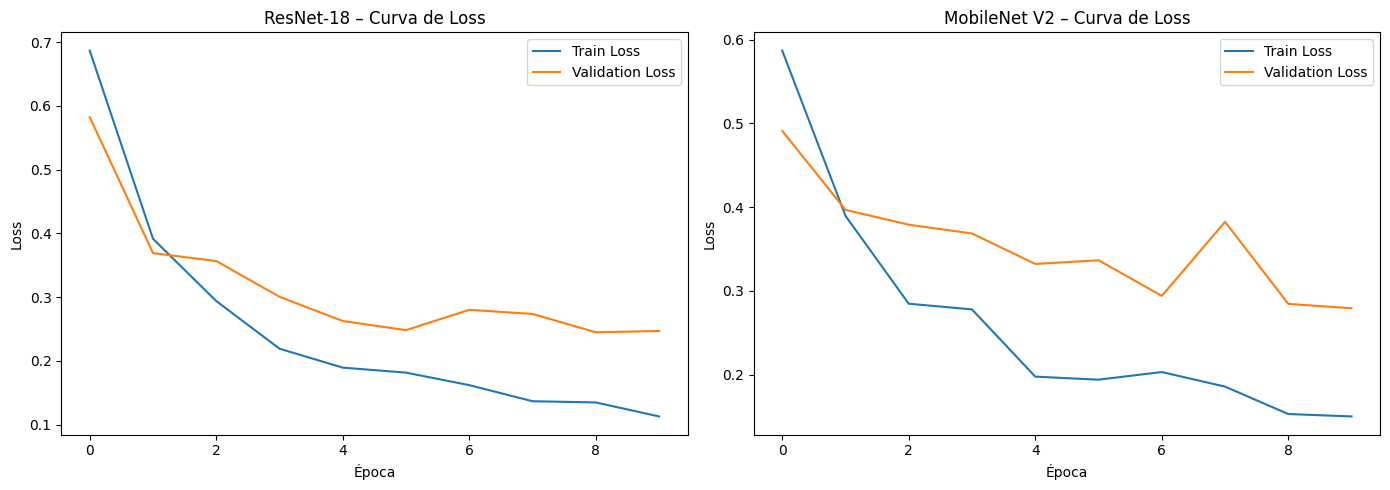

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ResNet-18
axes[0].plot(resnet_train_losses, label='Train Loss')
axes[0].plot(resnet_val_losses,   label='Validation Loss')
axes[0].set_title('ResNet-18 – Curva de Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MobileNet V2
axes[1].plot(mobilenet_train_losses, label='Train Loss')
axes[1].plot(mobilenet_val_losses,   label='Validation Loss')
axes[1].set_title('MobileNet V2 – Curva de Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Comparativo Final de Acurácia e Tempo

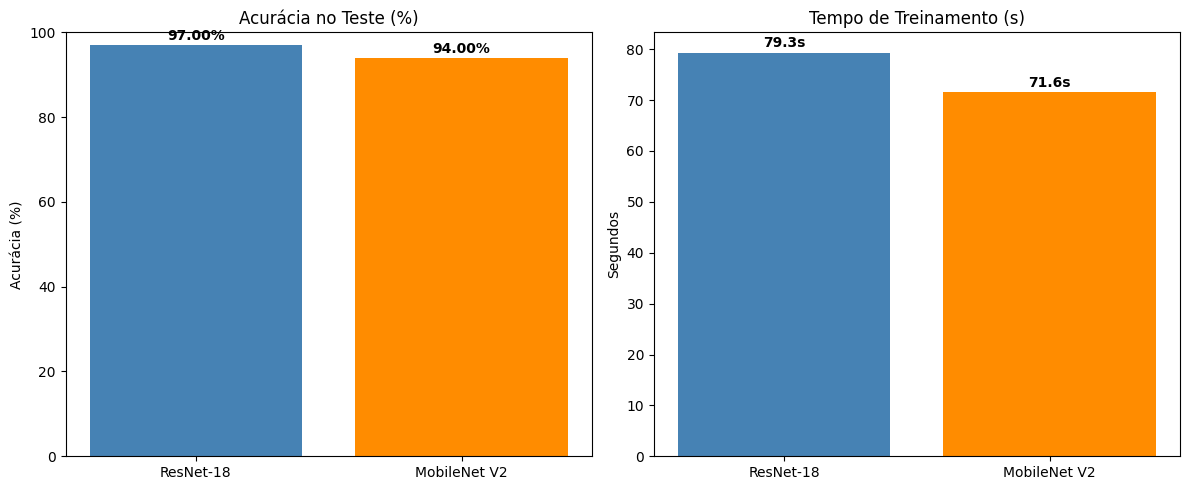

Resumo:
  ResNet-18       | Acurácia: 97.00% | Tempo: 79.35s
  MobileNet V2    | Acurácia: 94.00% | Tempo: 71.56s


In [13]:
modelos  = ['ResNet-18', 'MobileNet V2']
acuracias = [resnet_accuracy, mobilenet_accuracy]
tempos    = [resnet_time,     mobilenet_time]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Acurácia
bars = axes[0].bar(modelos, acuracias, color=['steelblue', 'darkorange'])
axes[0].set_title('Acurácia no Teste (%)')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Acurácia (%)')
for bar, val in zip(bars, acuracias):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Tempo de treinamento
bars2 = axes[1].bar(modelos, tempos, color=['steelblue', 'darkorange'])
axes[1].set_title('Tempo de Treinamento (s)')
axes[1].set_ylabel('Segundos')
for bar, val in zip(bars2, tempos):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Resumo:')
for modelo, acc, t in zip(modelos, acuracias, tempos):
    print(f'  {modelo:15s} | Acurácia: {acc:.2f}% | Tempo: {t:.2f}s')

## Geraçao de relatorio

In [14]:
import datetime

rTN, rFP, rFN, rTP = resnet_cm.ravel()
mTN, mFP, mFN, mTP = mobilenet_cm.ravel()

def metricas(TP, TN, FP, FN):
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

rP, rR, rF1 = metricas(rTP, rTN, rFP, rFN)
mP, mR, mF1 = metricas(mTP, mTN, mFP, mFN)

melhor      = 'ResNet-18' if resnet_accuracy >= mobilenet_accuracy else 'MobileNet V2'
mais_rapido = 'ResNet-18' if resnet_time <= mobilenet_time else 'MobileNet V2'

relatorio = f"""================================================================
RELATÓRIO – ETAPA 3: TRANSFER LEARNING
Gerado em: {datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')}
================================================================

CONFIGURAÇÕES GERAIS
---------------------
Dispositivo         : {DEVICE}
Tamanho da imagem   : 224x224 (RGB, 3 canais)
Batch size          : {BATCH_SIZE}
Épocas              : {EPOCHS}
Learning rate       : {LEARNING_RATE}
Otimizador          : Adam
Função de perda     : CrossEntropyLoss
Normalização        : ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

DATA AUGMENTATION
-----------------
1. RandomHorizontalFlip   (geométrico)
2. RandomRotation(10 graus) (rotação)
3. ColorJitter            (cor: brilho, contraste, saturação)

DATASET
-------
Amostras de treino      : {len(train_dataset)}
Amostras de validação   : {len(val_dataset)}
Amostras de teste       : {len(test_dataset)}
Total                   : {len(train_dataset) + len(val_dataset) + len(test_dataset)}
Classes                 : {train_dataset.classes}

================================================================
MODELO 1 – ResNet-18
================================================================
Arquitetura         : ResNet-18 (pré-treinada no ImageNet)
Fine-tuning         : Apenas camada fc (512 -> 2)
Camadas congeladas  : Todas exceto fc

Resultados do Treinamento:
  Loss final (treino)     : {resnet_train_losses[-1]:.4f}
  Loss final (validação)  : {resnet_val_losses[-1]:.4f}
  Loss mínima (treino)    : {min(resnet_train_losses):.4f} (época {resnet_train_losses.index(min(resnet_train_losses))+1})
  Loss mínima (validação) : {min(resnet_val_losses):.4f} (época {resnet_val_losses.index(min(resnet_val_losses))+1})
  Tempo de treinamento    : {resnet_time:.2f} segundos

Resultados no Teste:
  Acurácia   : {resnet_accuracy:.2f}%
  Precisão   : {rP:.4f}
  Recall     : {rR:.4f}
  F1-Score   : {rF1:.4f}

Matriz de Confusão:
                  Predito Gato   Predito Cachorro
Real Gato             {rTN:5d}            {rFP:5d}
Real Cachorro         {rFN:5d}            {rTP:5d}

================================================================
MODELO 2 – MobileNet V2
================================================================
Arquitetura         : MobileNet V2 (pré-treinada no ImageNet)
Fine-tuning         : Apenas classifier [Dropout + Linear(1280 -> 2)]
Camadas congeladas  : Todas exceto classifier

Resultados do Treinamento:
  Loss final (treino)     : {mobilenet_train_losses[-1]:.4f}
  Loss final (validação)  : {mobilenet_val_losses[-1]:.4f}
  Loss mínima (treino)    : {min(mobilenet_train_losses):.4f} (época {mobilenet_train_losses.index(min(mobilenet_train_losses))+1})
  Loss mínima (validação) : {min(mobilenet_val_losses):.4f} (época {mobilenet_val_losses.index(min(mobilenet_val_losses))+1})
  Tempo de treinamento    : {mobilenet_time:.2f} segundos

Resultados no Teste:
  Acurácia   : {mobilenet_accuracy:.2f}%
  Precisão   : {mP:.4f}
  Recall     : {mR:.4f}
  F1-Score   : {mF1:.4f}

Matriz de Confusão:
                  Predito Gato   Predito Cachorro
Real Gato             {mTN:5d}            {mFP:5d}
Real Cachorro         {mFN:5d}            {mTP:5d}

================================================================
COMPARATIVO FINAL
================================================================
  Modelo           Acurácia    Precisão    Recall    F1-Score  Tempo
  ResNet-18        {resnet_accuracy:6.2f}%    {rP:.4f}      {rR:.4f}    {rF1:.4f}    {resnet_time:.1f}s
  MobileNet V2     {mobilenet_accuracy:6.2f}%    {mP:.4f}      {mR:.4f}    {mF1:.4f}    {mobilenet_time:.1f}s

  Maior acurácia  : {melhor}
  Mais rápido     : {mais_rapido}
================================================================
"""

print(relatorio)

with open('relatorio_transfer.txt', 'w', encoding='utf-8') as f:
    f.write(relatorio)

print('Relatório salvo em: relatorio_transfer.txt')

RELATÓRIO – ETAPA 3: TRANSFER LEARNING
Gerado em: 22/06/2026 18:56:53

CONFIGURAÇÕES GERAIS
---------------------
Dispositivo         : cuda
Tamanho da imagem   : 224x224 (RGB, 3 canais)
Batch size          : 32
Épocas              : 10
Learning rate       : 0.001
Otimizador          : Adam
Função de perda     : CrossEntropyLoss
Normalização        : ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

DATA AUGMENTATION
-----------------
1. RandomHorizontalFlip   (geométrico)
2. RandomRotation(10 graus) (rotação)
3. ColorJitter            (cor: brilho, contraste, saturação)

DATASET
-------
Amostras de treino      : 300
Amostras de validação   : 100
Amostras de teste       : 100
Total                   : 500
Classes                 : ['cat', 'dog']

MODELO 1 – ResNet-18
Arquitetura         : ResNet-18 (pré-treinada no ImageNet)
Fine-tuning         : Apenas camada fc (512 -> 2)
Camadas congeladas  : Todas exceto fc

Resultados do Treinamento:
  Loss final (treino)     : 0.1130
